In [1]:
# Step 1 — Imports & Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Use seaborn's built-in Titanic — no Kaggle account needed
df = sns.load_dataset('titanic')

# ── First look ──────────────────────────────────────────
print("Shape:", df.shape)          # (891, 15)
print(df.head())
print(df.info())
print(df.isnull().sum())          # null counts per column
print(df.describe())              # numeric summary stats

# ── Null summary as % ───────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
print(null_pct[null_pct > 0])

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   surviv

Overall survival rate: 38.4%
survived
Died        549
Survived    342
Name: count, dtype: int64


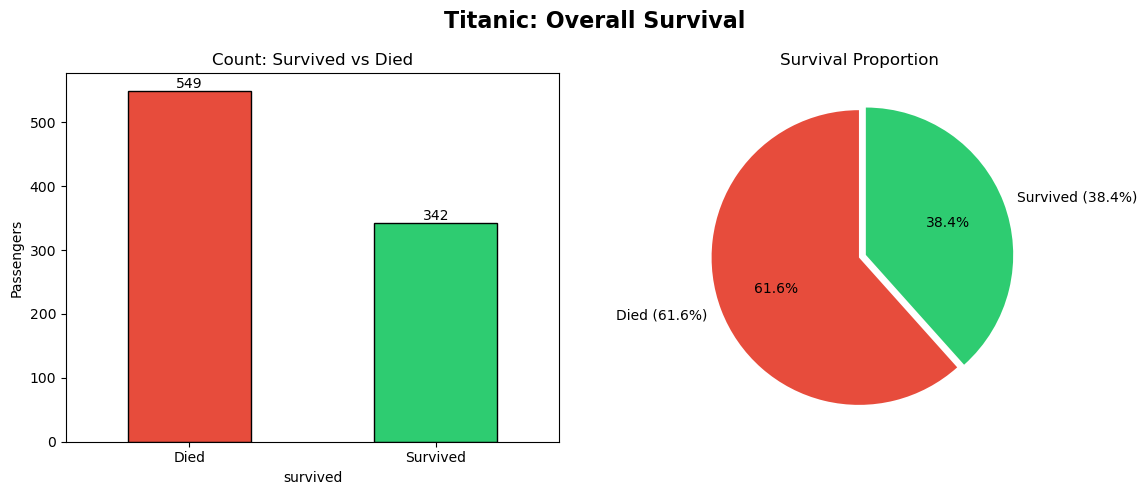

In [2]:
# Q1 — Overall survival rate
survival_rate = df['survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Count breakdown
counts = df['survived'].value_counts()
print(counts.rename({0: 'Died', 1: 'Survived'}))

# ── Visualization 1: Survival Counts ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Titanic: Overall Survival', fontsize=16, fontweight='bold')

# Bar chart
colors = ['#e74c3c', '#2ecc71']
df['survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='black', width=0.5)
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)
axes[0].set_title('Count: Survived vs Died')
axes[0].set_ylabel('Passengers')
for p in axes[0].patches:       # add count labels on bars
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()+5), ha='center')

# Pie chart
axes[1].pie([549, 342], labels=['Died (61.6%)', 'Survived (38.4%)'],
    colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Survival Proportion')

plt.tight_layout()
plt.savefig('titanic_01_overall.png', dpi=150, bbox_inches='tight')
plt.show()

        count  survived  survival_rate
sex                                   
female    314       233          0.742
male      577       109          0.189
        Died  Survived  Total
sex                          
female    81       233    314
male     468       109    577
Total    549       342    891


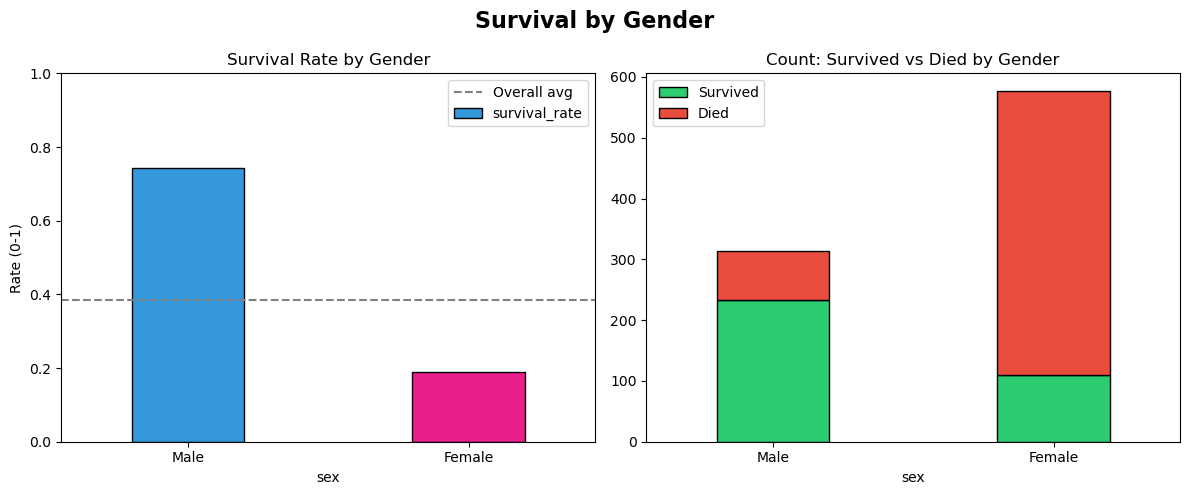

In [3]:
# Q2 — Survival by gender
gender_survival = df.groupby('sex')['survived'].agg(
    count='count',
    survived='sum',
    survival_rate='mean'
).round(3)
print(gender_survival)

# Crosstab for counts
ct = pd.crosstab(df['sex'], df['survived'],
                 margins=True, margins_name='Total')
ct.columns = ['Died', 'Survived', 'Total']
print(ct)

# ── Visualization 2: Gender survival ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Survival by Gender', fontsize=16, fontweight='bold')

# Rate comparison
gender_survival['survival_rate'].plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e91e8c'], edgecolor='black', width=0.4)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Rate (0-1)')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.384, ls='--', color='gray', label='Overall avg')
axes[0].legend()
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)

# Stacked counts
ct_plot = ct.drop('Total')[['Survived', 'Died']]
ct_plot.plot(kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
axes[1].set_title('Count: Survived vs Died by Gender')
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)

plt.tight_layout()
plt.savefig('titanic_02_gender.png', dpi=150)
plt.show()

        count  survived  survival_rate
pclass                                
1         216       136          0.630
2         184        87          0.473
3         491       119          0.242
sex       female      male
pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


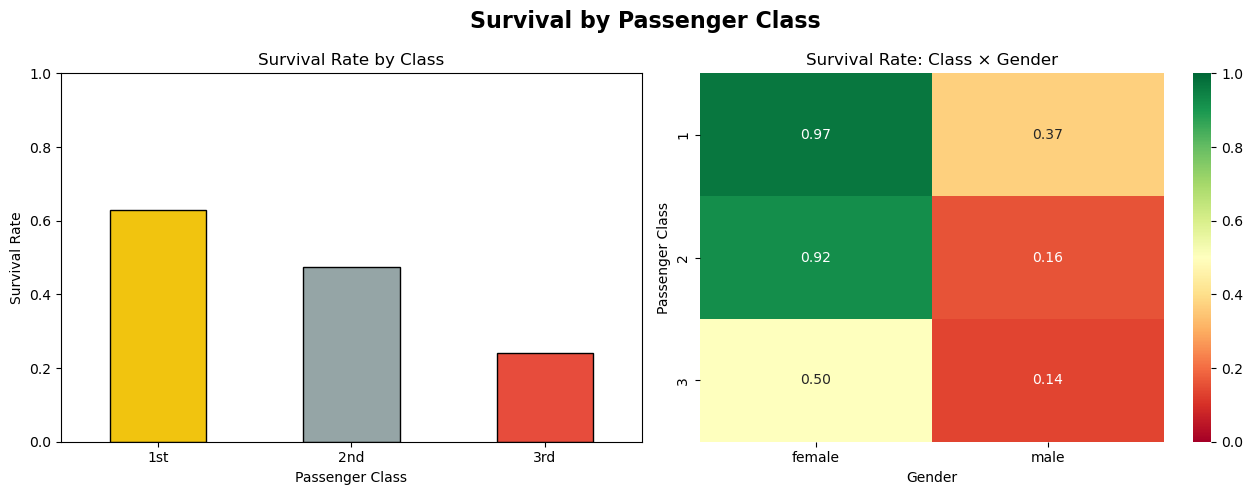

In [4]:
# Q3 — Survival by passenger class
class_survival = df.groupby('pclass')['survived'].agg(
    count='count',
    survived='sum',
    survival_rate='mean'
).round(3)
print(class_survival)

# Cross-tabulation: class × gender × survival
cross = df.groupby(['pclass', 'sex'])['survived'].mean().unstack()
print(cross)

# ── Visualization 3: Class + heatmap ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Survival by Passenger Class', fontsize=16, fontweight='bold')

# Bar: survival rates per class
class_survival['survival_rate'].plot(kind='bar', ax=axes[0],
    color=['#f1c40f', '#95a5a6', '#e74c3c'],
    edgecolor='black', width=0.5)
axes[0].set_title('Survival Rate by Class')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

# Heatmap: class × gender survival
sns.heatmap(cross, annot=True, fmt='.2f', cmap='RdYlGn',
    ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Survival Rate: Class × Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Passenger Class')

plt.tight_layout()
plt.savefig('titanic_03_class.png', dpi=150)
plt.show()

Median age - Survived: 28.0
Median age - Died:     28.0


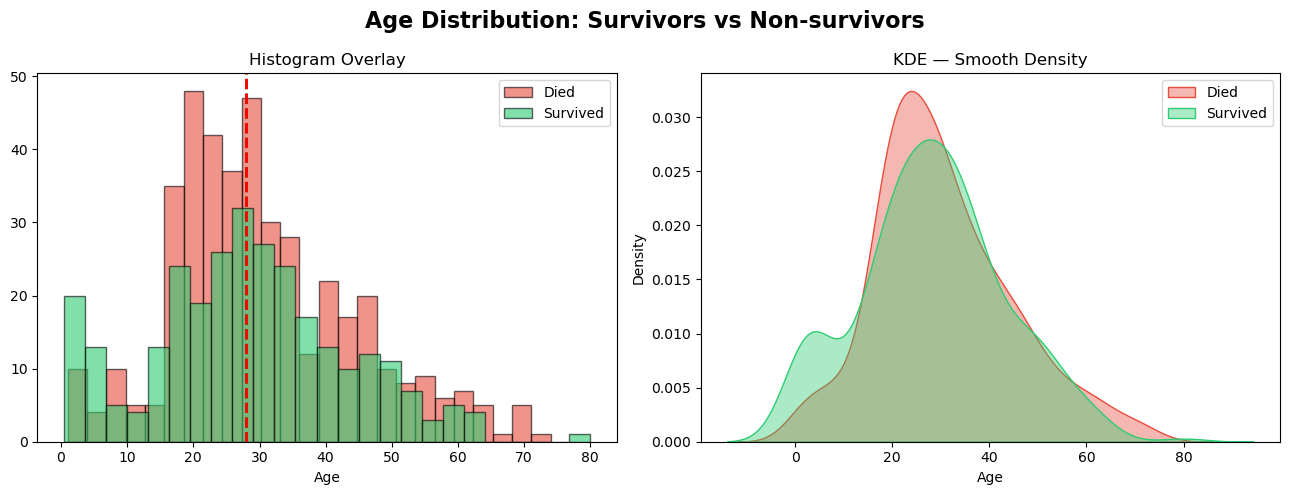

In [5]:
# Q4 — Age distribution: survivors vs non-survivors

# Boolean masks
survived_ages = df[df['survived'] == 1]['age'].dropna()
died_ages     = df[df['survived'] == 0]['age'].dropna()

# Summary statistics
print("Median age - Survived:", survived_ages.median())
print("Median age - Died:    ", died_ages.median())

# ── Visualization 4: Age distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Age Distribution: Survivors vs Non-survivors',
    fontsize=16, fontweight='bold')

# Histogram overlay
axes[0].hist(died_ages, bins=25, alpha=0.6,
    color='#e74c3c', label='Died', edgecolor='black')
axes[0].hist(survived_ages, bins=25, alpha=0.6,
    color='#2ecc71', label='Survived', edgecolor='black')
axes[0].axvline(survived_ages.median(), color='green', ls='--', lw=2)
axes[0].axvline(died_ages.median(), color='red', ls='--', lw=2)
axes[0].legend()
axes[0].set_title('Histogram Overlay')
axes[0].set_xlabel('Age')

# KDE (smooth density) plot using seaborn
sns.kdeplot(died_ages, ax=axes[1], color='#e74c3c',
    fill=True, alpha=0.4, label='Died')
sns.kdeplot(survived_ages, ax=axes[1], color='#2ecc71',
    fill=True, alpha=0.4, label='Survived')
axes[1].set_title('KDE — Smooth Density')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('titanic_04_age.png', dpi=150)
plt.show()

                     passengers  survival_rate
embark_full                                   
Cherbourg, France           168          0.554
Queenstown, Ireland          77          0.390
Southampton, UK             644          0.337


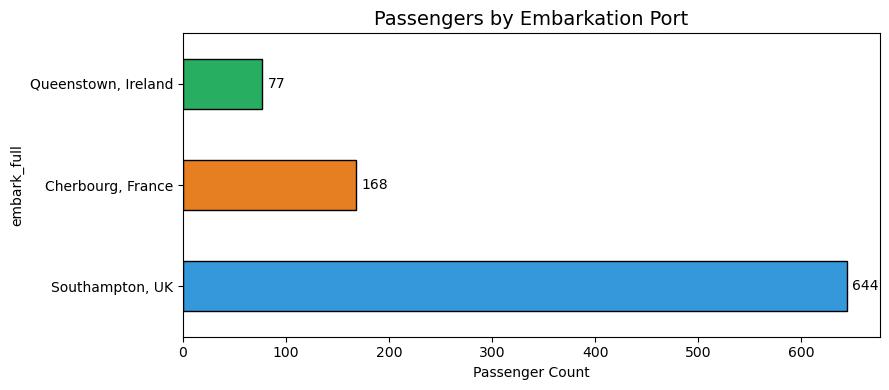

In [6]:
# Q5 — Embarkation ports (Titanic only has 3,
#       but this pattern works on any dataset)

port_map = {'S': 'Southampton, UK',
            'C': 'Cherbourg, France',
            'Q': 'Queenstown, Ireland'}

df['embark_full'] = df['embarked'].map(port_map)

port_counts = df['embark_full'].value_counts()
port_survival = df.groupby('embark_full')['survived'].mean()

print(pd.DataFrame({
    'passengers': port_counts,
    'survival_rate': port_survival.round(3)
}))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 4))
port_counts.plot(kind='barh', ax=ax,
    color=['#3498db', '#e67e22', '#27ae60'],
    edgecolor='black')
ax.set_title('Passengers by Embarkation Port', fontsize=14)
ax.set_xlabel('Passenger Count')
for i, v in enumerate(port_counts):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.savefig('titanic_05_ports.png', dpi=150)
plt.show()